# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
# import requests

# url = "https://raw.githubusercontent.com/cobanov/shakespeare-dataset/main/text/hamlet_TXT_FolgerShakespeare.txt"
# corpus = requests.get(url).text[0:5000]
# print(corpus[:500])

In [ ]:
corpus = '''
This biographical article related to French artistic gymnastics is a stub. You can help Wikipedia by expanding it.
InsideAR was the largest Augmented Reality event in Europe. It was organized and supported by metaio GmbH every year. The first event was held in 2010, had since expanded globally and was run at multiple locations around the world.  However, after Apple purchased metaio in May 2015, metaio cancelled the InsideAR conference 2015 without any statements about the conference's future.
The Fearing Mind is an American horror television series that aired on the Fox Family Channel from October 21 until December 2, 2000.
Bill Fearing, a famous writer of suspense thrillers, gets his ideas from things that happen in his family. When he gets an idea, the viewers enter his mind and see the gruesome events unfold.
It had a bronze barrel and lacked a modern recoil system, using only an ineffective spring-mounted spade brake, and was virtually obsolescent on its introduction. Nonetheless, it was the standard field howitzer for the Austrian Army at the outbreak of the war.
Lithuanian Paralympic Committee (Lithuanian: Lietuvos parolimpinis komitetas) was founded on 1990 and recognized by the International Paralympic Committee after one year.
A GUI may be designed for the requirements of a vertical market as application-specific graphical user interfaces. Examples include automated teller machines (ATM), point of sale (POS) touchscreens at restaurants, self-service checkouts used in a retail store, airline self-ticket and check-in, information kiosks in a public space, like a train station or a museum, and monitors or control screens in an embedded industrial application which employ a real-time operating system (RTOS).
Cell phones and handheld game systems also employ application specific touchscreen GUIs. Newer automobiles use GUIs in their navigation systems and multimedia centers, or navigation multimedia center combinations.
A GUI uses a combination of technologies and devices to provide a platform that users can interact with, for the tasks of gathering and producing information.
A series of elements conforming a visual language have evolved to represent information stored in computers. This makes it easier for people with few computer skills to work with and use computer software. The most common combination of such elements in GUIs is the windows, icons, menus, pointer (WIMP) paradigm, especially in personal computers.
In personal computers, all these elements are modeled through a desktop metaphor to produce a simulation called a desktop environment in which the display represents a desktop, on which documents and folders of documents can be placed. Window managers and other software combine to simulate the desktop environment with varying degrees of realism.
Entries may appear in a list to make space for text and details, or in a grid for compactness and larger icons with little space underneath for text. Variations inbetween exist, such as a list with multiple columns of items and a grid of items with rows of text extending sideways from the icon.
Multi-row and multi-column layouts commonly found on the web are "shelf" and "waterfall". The former is found on image search engines, where images appear with a fixed height but variable length, and is typically implemented with the CSS property and parameter display: inline-block;. A waterfall layout found on Imgur and Tweetdeck with fixed width but variable height per item is usually implemented by specifying column-width:.
Smaller app mobile devices such as personal digital assistants (PDAs) and smartphones typically use the WIMP elements with different unifying metaphors, due to constraints in space and available input devices. Applications for which WIMP is not well suited may use newer interaction techniques, collectively termed post-WIMP user interfaces.
As of 2011, some touchscreen-based operating systems such as Apple's iOS (iPhone) and Android use the class of GUIs named post-WIMP. These support styles of interaction using more than one finger in contact with a display, which allows actions such as pinching and rotating, which are unsupported by one pointer and mouse.
Human interface devices, for the efficient interaction with a GUI include a computer keyboard, especially used together with keyboard shortcuts, pointing devices for the cursor (or rather pointer) control: mouse, pointing stick, touchpad, trackball, joystick, virtual keyboards, and head-up displays (translucent information devices at the eye level).
There are also actions performed by programs that affect the GUI. For example, there are components like inotify or D-Bus to facilitate communication between computer programs.
GUIs were a hot topic in the early 1980s. The Apple Lisa was released in 1983, and various windowing systems existed for DOS operating systems (including PC GEM and PC/GEOS). Individual applications for many platforms presented their own GUI variants. Despite the GUIs advantages, many reviewers questioned the value of the entire concept, citing hardware limits, and problems in finding compatible software.
In 1984, Apple released a television commercial which introduced the Apple Macintosh during the telecast of Super Bowl XVIII by CBS, with allusions to George Orwell's noted novel Nineteen Eighty-Four. The goal of the commercial was to make people think about computers, identifying the user-friendly interface as a personal computer which departed from prior business-oriented systems, and becoming a signature representation of Apple products.
Windows 95, accompanied by an extensive marketing campaign, was a major success in the marketplace at launch and shortly became the most popular desktop operating system.
In 2007, with the iPhone and later in 2010 with the introduction of the iPad,  Apple popularized the post-WIMP style of interaction for multi-touch screens, and those devices were considered to be milestones in the development of mobile devices.
The GUIs familiar to most people as of the mid-late 2010s are Microsoft Windows, macOS, and the X Window System interfaces for desktop and laptop computers, and Android, Apple's iOS, Symbian, BlackBerry OS, Windows Phone/Windows 10 Mobile, Tizen, WebOS, and Firefox OS for handheld (smartphone) devices.[citation needed]
GUIs can be made quite hard when dialogs are buried deep in a system or moved about to different places during redesigns. Also, icons and dialog boxes are usually harder for users to script.
WIMPs extensively use modes, as the meaning of all keys and clicks on specific positions on the screen are redefined all the time. Command-line interfaces use modes only in limited forms, such as for current directory and environment variables.
Most modern operating systems provide both a GUI and some level of a CLI, although the GUIs usually receive more attention. The GUI is usually WIMP-based, although occasionally other metaphors surface, such as those used in Microsoft Bob, 3dwm, or File System Visualizer.
Several attempts have been made to create a multi-user three-dimensional environment or 3D GUI, including Sun's Project Looking Glass, Metisse, which was similar to Project Looking Glass, BumpTop, where users can manipulate documents and windows with realistic movement and physics as if they were physical documents, and the Croquet Project, which moved to the Open Cobalt and Open Croquet efforts.
The zooming user interface (ZUI) is a related technology that promises to deliver the representation benefits of 3D environments without their usability drawbacks of orientation problems and hidden objects. It is a logical advance on the GUI, blending some three-dimensional movement with two-dimensional or 2.5D vector objects. In 2006, Hillcrest Labs introduced the first zooming user interface for television.
Some environments use the methods of 3D graphics to project virtual three-dimensional user interface objects onto the screen. These are often shown in use in science fiction films (see below for examples). As the processing power of computer graphics hardware increases, this becomes less of an obstacle to a smooth user experience.
Three-dimensional graphics are currently mostly used in computer games, art, and computer-aided design (CAD). A three-dimensional computing environment can also be useful in other uses, like molecular graphics, aircraft design and Phase Equilibrium Calculations/Design of unit operations and chemical processes.

'''

print(corpus[:500])


This biographical article related to French artistic gymnastics is a stub. You can help Wikipedia by expanding it.
InsideAR was the largest Augmented Reality event in Europe. It was organized and supported by metaio GmbH every year. The first event was held in 2010, had since expanded globally and was run at multiple locations around the world.  However, after Apple purchased metaio in May 2015, metaio cancelled the InsideAR conference 2015 without any statements about the conference's future. 


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 631
X shape: (1294, 75)
y shape: (1294,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

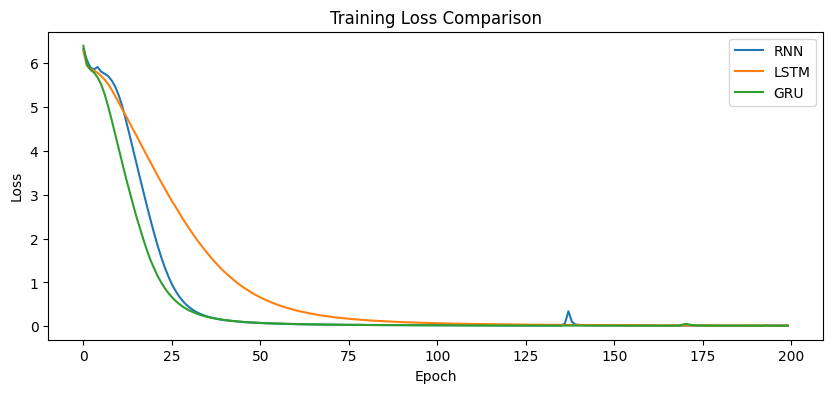

In [76]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [77]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [78]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM :", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning and some environments use the methods of 3d graphics to
LSTM : deep learning had a bronze barrel and lacked a modern recoil system
GRU : deep learning with a gui include a computer keyboard especially used together


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**